In [1]:
#MILESTONE 2: TOPIC EXTRATION & FEATURE ANALYSIS
#Importing libraries
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
from collections import Counter 
import re
import warnings
warnings.filterwarnings('ignore')

#for text preprocessions and NLP libraries
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.sentiment import SentimentIntensityAnalyzer 

#TF-IDF and machine learning
from sklearn.feature_extraction.text import TfidfVectorizer

#Downloading required NLTK data 
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('vader_lexicon')
nltk.download('omw-1.4')

#TF-IDF and machine learning
from sklearn.feature_extraction.text import TfidfVectorizer

print("All libraries imported successfully")


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...


All libraries imported successfully


[nltk_data]   Package omw-1.4 is already up-to-date!


In [2]:
print("="*60)
print("Step 1: TEXT PREPROCESSING")
print("="*60)

#Loading the cleaned dataset from milestone 1
clean_reviews_df=pd.read_csv('clean_health_reviews.csv') #clean_reviews Loaded

print(f"Dataset loaded: {len(clean_reviews_df)} reviews")
print(f"\nColumns:{list(clean_reviews_df.columns)}")
print(f"\nFirst 3 reviews:")
print(clean_reviews_df[['App', 'Translated_Review', 'Rating']].head(3))

def simple_preprocess(text):
    """
    Simple preprocessing 
    """
    #converting to string & lowercase
    text=str(text).lower()

    #removing urls and emails
    text=re.sub(r'http\S+|www\S+', '', text) 
    text=re.sub(r'\S+@\S+', '', text)

    #removing special characters and numbers (keeping only letters and spaces)
    text=re.sub(r'[^a-z\s]', ' ', text)

    #removing extra space
    text=re.sub(r'\s+', ' ', text.strip())

    return text

#applying preprocessing
print("\nApplying preprocessing...")
clean_reviews_df['processed_text'] = clean_reviews_df['Translated_Review'].apply(simple_preprocess)

#Removing empty reviews
clean_reviews_df = clean_reviews_df[clean_reviews_df['processed_text'].str.len()>5].reset_index(drop=True)
print(f"After removing empty reviews:{len(clean_reviews_df)} reviews remaining")

print("Text preprocessing completed")

#Example
print("="*60)
print("PREPROCESSING EXAMPLES")
print("="*60)
for i in range (min(3, len(clean_reviews_df))):
    print(f"\nExample {i+1}:")
    print(f"Original: {clean_reviews_df.iloc[i]['Translated_Review']}")
    print(f"Processed: {clean_reviews_df.iloc[i]['processed_text']}")

#saving processed_text
clean_reviews_df.to_csv('preprocessed.csv', index=False)
print("\n Preprocessed data saved!")

Step 1: TEXT PREPROCESSING
Dataset loaded: 168 reviews

Columns:['App', 'Translated_Review', 'Sentiment', 'Sentiment_Polarity', 'Sentiment_Subjectivity', 'Rating']

First 3 reviews:
                                          App  \
0  30 Day Fitness Challenge - Workout at Home   
1  30 Day Fitness Challenge - Workout at Home   
2  30 Day Fitness Challenge - Workout at Home   

                                   Translated_Review  Rating  
0  It'd great u added exercises. I mean chest, ba...     4.8  
1  Some times exercises match designated body par...     4.8  
2                     Helped get ideal body I wanted     4.8  

Applying preprocessing...
After removing empty reviews:168 reviews remaining
Text preprocessing completed
PREPROCESSING EXAMPLES

Example 1:
Original: It'd great u added exercises. I mean chest, back, shoulders.
Processed: it d great u added exercises i mean chest back shoulders

Example 2:
Original: Some times exercises match designated body parts aim work on. But 

In [3]:
print("="*60)
print("Step 2: KEYWORD EXTRACTION USING TF-IDF")
print("="*60)

#Initialize TF-IDF Vectorizer 
tfidf_vectorizer=TfidfVectorizer (
    max_features=100,    #Top 100 features 
    min_df=2,            #Word must appear at least 2 documents   
    max_df=0.8,          #Word must not appear in more than 80% of documents
    ngram_range=(1,2),   #for Unigrams and bigrams
    stop_words='english' #To remove common words
)
#Fit and transform the processed text 
tfidf_matrix = tfidf_vectorizer.fit_transform(clean_reviews_df['processed_text'])
feature_names = tfidf_vectorizer.get_feature_names_out() 

print(f"TF-IDF matrix shape: {tfidf_matrix.shape}")
print(f"Number of keywords: {len(feature_names)}")

#claculating average TF-IDF score for each keyword across all documents 
tfidf_scores = np.asarray(tfidf_matrix.mean(axis=0)).flatten()

#creating keyword dataframe
keyword_df = pd.DataFrame ({
    'keyword': feature_names,
    'tfidf_score': tfidf_scores
}).sort_values('tfidf_score', ascending=False)

#Top 50 keywords
print(f"\nTop 50 keywords:")
print("=" * 60)
print(keyword_df.head(50).to_string(index=False))

keyword_df.to_csv('tfidf_keywords.csv',index=False)
print("Keywords saved to 'tfidf_keywords.csv'")

Step 2: KEYWORD EXTRACTION USING TF-IDF
TF-IDF matrix shape: (168, 100)
Number of keywords: 100

Top 50 keywords:
  keyword  tfidf_score
      app     0.077888
    great     0.076746
     good     0.056671
     like     0.052937
   really     0.043412
     easy     0.042749
     work     0.041552
      day     0.039409
      way     0.039154
     food     0.039091
  workout     0.038978
 workouts     0.037880
 exercise     0.037415
     make     0.036972
     love     0.035407
    track     0.034820
 calories     0.032434
      log     0.031596
     body     0.030926
      let     0.030890
      ads     0.029870
       ve     0.027635
    keeps     0.025360
     need     0.025039
  fitness     0.024969
   better     0.024812
     days     0.024168
      lot     0.023859
     want     0.023741
  working     0.023421
     best     0.022825
   fitbit     0.022613
     sync     0.022580
exercises     0.022553
great app     0.022209
  calorie     0.020992
    tried     0.020628
   option   

Step 3: FEATURE CATEGORY IDENTIFICATION
Feature Mention Frequency:
 Feature Category  Mention Count  Percentage
Calorie/Nutrition             83       49.40
 Workout Tracking             54       32.14
   User Interface             43       25.60
Progress Tracking             40       23.81
 Sync/Integration             29       17.26
 Customer Support             22       13.10
    Premium/Price             16        9.52
   Bugs/Technical             11        6.55
       Motivation             10        5.95
     Offline Mode              1        0.60


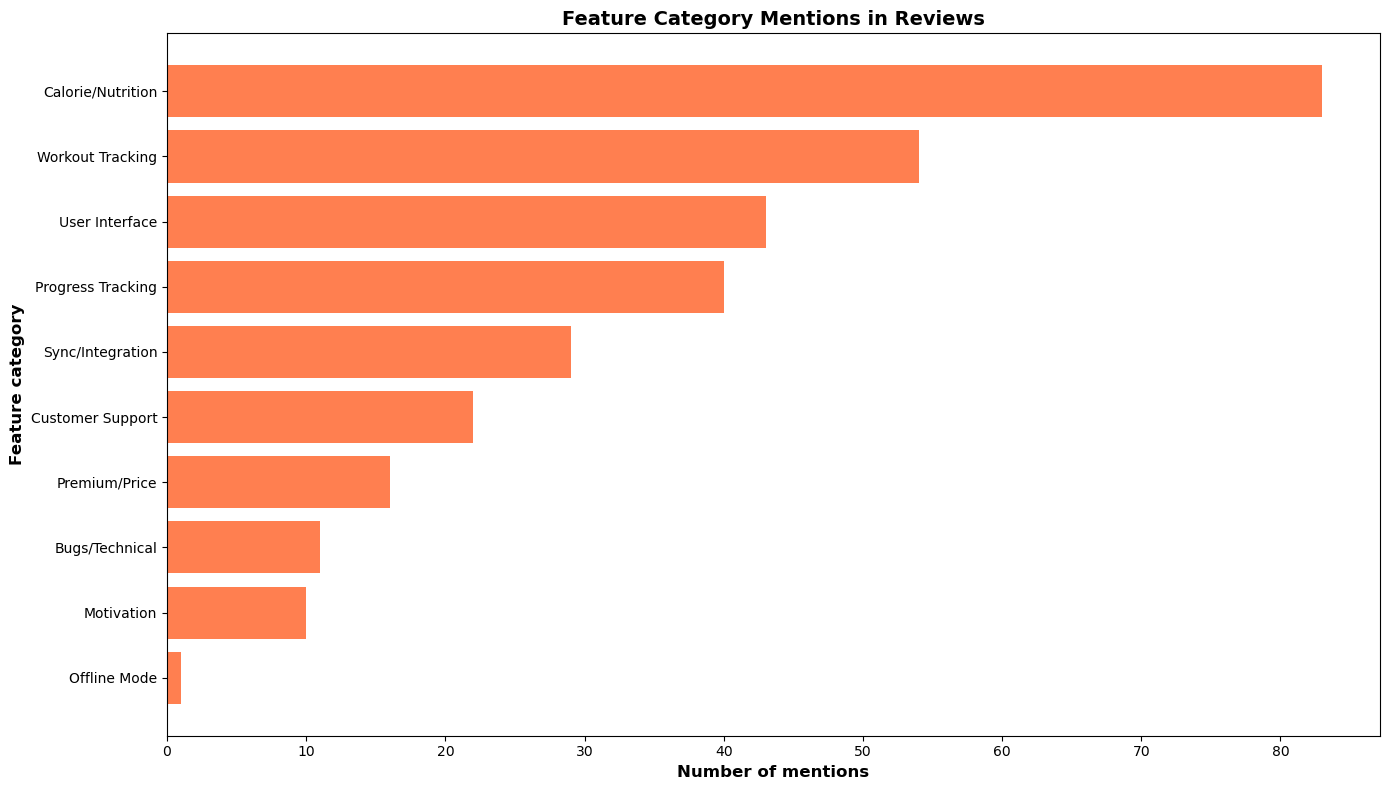

Data saved to 'feature_mentions.csv'


In [4]:
print("="*60)
print("Step 3: FEATURE CATEGORY IDENTIFICATION")
print("="*60)

#Defining feature categories 
feature_categories = {
    'Workout Tracking': ['workout', 'exercise', 'training', 'routine', 'session', 'rep', 'set'],
    'Calorie/Nutrition': ['calorie', 'calories', 'food', 'nutrition', 'diet', 'meal', 'eat'],
    'User Interface': ['interface', 'design', 'easy', 'simple', 'screen', 'layout', 'ui'],
    'Sync/Integration': ['sync', 'syncing', 'connect', 'fitbit', 'garmin', 'watch', 'device'],
    'Offline Mode': ['offline', 'internet', 'connection', 'online', 'wifi'],
    'Premium/Price': ['premium', 'subscription', 'paid', 'price', 'expensive', 'free', 'cost'],
    'Bugs/Technical': ['bug', 'crash', 'error', 'freeze', 'slow', 'loading', 'problem'],
    'Customer Support': ['support', 'help', 'customer', 'service'],
    'Progress Tracking': ['progress', 'track', 'tracking', 'goal', 'result'],
    'Motivation': ['motivate', 'motivation', 'inspire', 'challenge']
}

def check_feature(text, keywords):
    """
    Checking if any keyword appers in text 
    """
    text_lower = text.lower()
    return any(keyword in text_lower for keyword in keywords)

#Count mention
feature_data = []
for category, keywords in feature_categories.items():
    mentions = clean_reviews_df['Translated_Review'].apply(lambda x: check_feature(str(x), keywords))
    count = mentions.sum()
    percentage = (count/len(clean_reviews_df)*100)

    feature_data.append({
    'Feature Category' : category,
    'Mention Count' : count,
    'Percentage' : round(percentage,2)
    })

    #adding column 
    clean_reviews_df[f'mentions_{category}'] = mentions

feature_mention_df = pd.DataFrame(feature_data).sort_values('Mention Count', ascending = False)
print("Feature Mention Frequency:")
print("=" *60)
print(feature_mention_df.to_string(index=False))

#Visualization: Feature mentions
plt.figure(figsize=(14,8))
plt.barh(range(len(feature_mention_df)), feature_mention_df['Mention Count'], color='coral')
plt.yticks(range(len(feature_mention_df)), feature_mention_df['Feature Category'])
plt.xlabel('Number of mentions', fontsize=12, fontweight='bold')
plt.ylabel('Feature category', fontsize=12, fontweight='bold')
plt.title('Feature Category Mentions in Reviews', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_mentions.png', dpi=300, bbox_inches='tight')
plt.show()

feature_mention_df.to_csv('feature_mentions.csv', index=False)
print("Data saved to 'feature_mentions.csv'")

Step 4: SENTIMENT ANALYSIS BY FEATURE CATEGORY
Calculating VADER sentiment scores..
Sentiment Analysis by Feature Category:
 Feature Category  Mention Count  Avg Sentiment  Positive %  Negative %  Neutral %  Net Sentiment
     Offline Mode              1          0.806       100.0         0.0        0.0          100.0
   User Interface             43          0.663        88.4         7.0        4.7           81.4
Progress Tracking             40          0.645        90.0        10.0        0.0           80.0
       Motivation             10          0.617        90.0        10.0        0.0           80.0
Calorie/Nutrition             83          0.609        85.5        10.8        3.6           74.7
    Premium/Price             16          0.600        87.5        12.5        0.0           75.0
 Workout Tracking             54          0.557        83.3        14.8        1.9           68.5
 Customer Support             22          0.503        81.8        13.6        4.5          

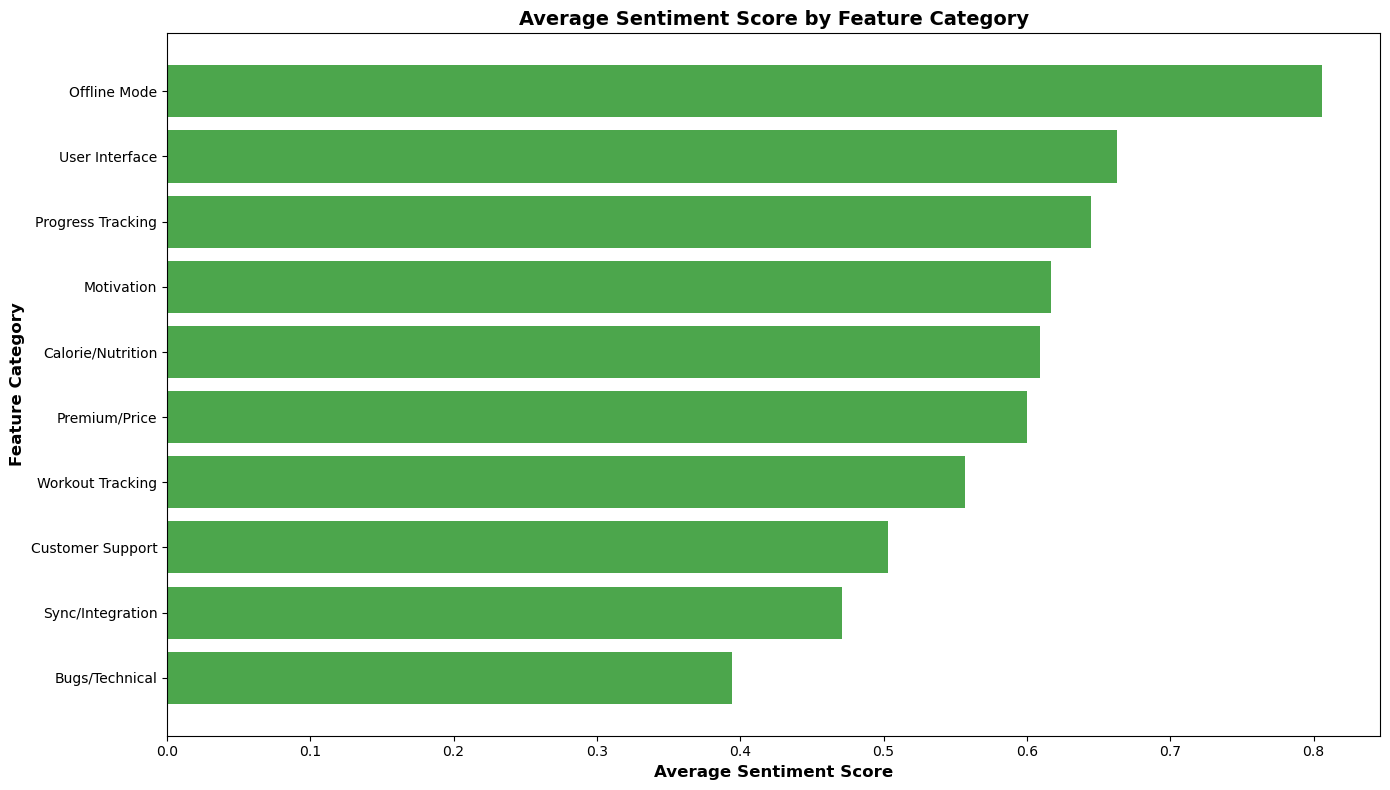


 Sentiment by feature chart saved as 'sentiment_by_feature.png'


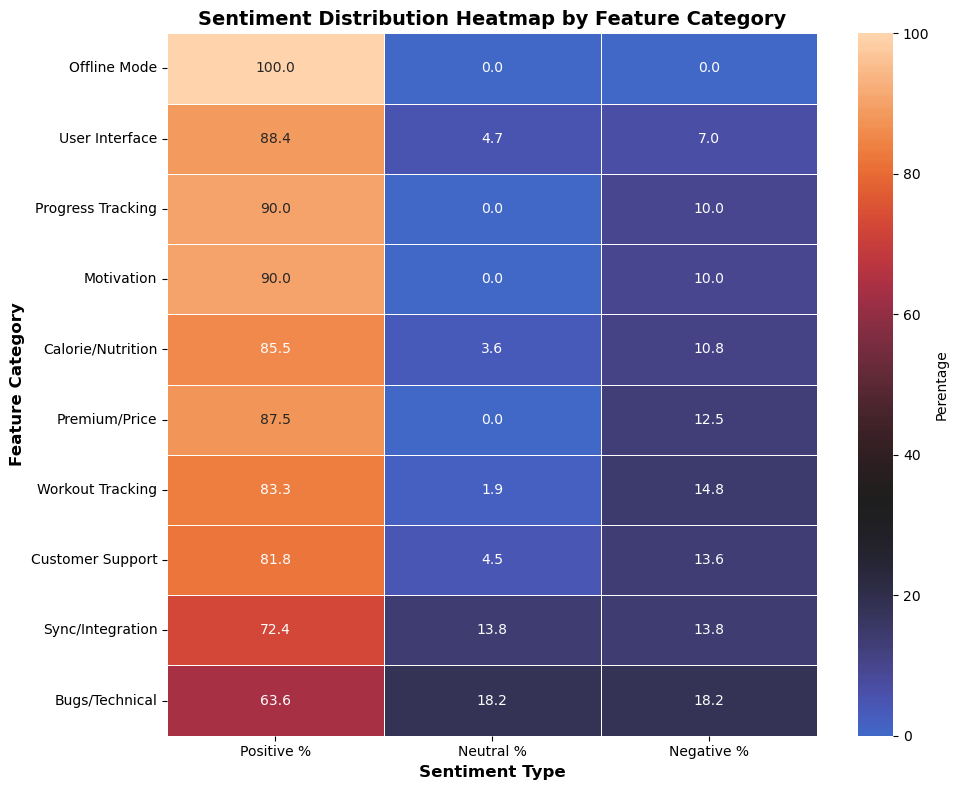

Sentiment heatmap saved as 'sentiment_heatmap.png'
Sentiment by feature data saved to 'sentiment_by_feature.csv'


In [5]:
print("="*60)
print("Step 4: SENTIMENT ANALYSIS BY FEATURE CATEGORY")
print("="*60)

#using vader sentiment from milestone 1
if 'VaderCompound' not in clean_reviews_df.columns:
    print("Calculating VADER sentiment scores..")
    sia = SentimentIntensityAnalyzer()

    def get_vader_scores(text):
        scores = sia.polarity_scores(text)
        return scores['compound']

    clean_reviews_df['VaderCompound'] = clean_reviews_df['Translated_Review'].apply(get_vader_scores)

    #Classify statement
    def classify_statement(score):
        if score>= 0.05:
            return 'Positive'
        elif score<=-0.05:
            return 'Negative'
        else:
            return 'Neutral'
    clean_reviews_df['VaderSentiment']= clean_reviews_df['VaderCompound'].apply(classify_statement)

#calculating sentiment by feature category
sentiment_by_feature_data = []

for category in feature_categories.keys():
    #Filtering reviews mentioning this feature
    feature_reviews = clean_reviews_df[clean_reviews_df[f'mentions_{category}'] == True]

    if len(feature_reviews) > 0 :
        #calculate the average sentiment 
        avg_sentiment = feature_reviews['VaderCompound'].mean()

        #calculate sentiment distribution 
        sentiment_counts = feature_reviews['VaderSentiment'].value_counts()
        total = len(feature_reviews)

        positive_pct = (sentiment_counts.get('Positive', 0) / total) * 100
        negative_pct = (sentiment_counts.get('Negative', 0) / total) * 100
        neutral_pct = (sentiment_counts.get('Neutral', 0) / total) * 100

        #net sentiment
        net_sentiment = positive_pct - negative_pct 

        sentiment_by_feature_data.append({
            'Feature Category': category,
            'Mention Count': len(feature_reviews),
            'Avg Sentiment': round(avg_sentiment, 3),
            'Positive %': round(positive_pct, 1),
            'Negative %': round(negative_pct, 1),
            'Neutral %': round(neutral_pct, 1),
            'Net Sentiment': round(net_sentiment,1)
        })

#creating sentiment by feature dataframe
sentiment_by_feature_df = pd.DataFrame(sentiment_by_feature_data).sort_values('Avg Sentiment', ascending=False)

print("Sentiment Analysis by Feature Category:")
print("=" * 60)
print(sentiment_by_feature_df.to_string(index=False))

#identifying most positive and mos negative features

print("="*60)
print("KEY INSIGHTS")
print("="*60)      
print("\nMost Positively Perceived Featuers:")
top_positive = sentiment_by_feature_df.head(3) 
for idx, row in top_positive.iterrows():
    print(f" {row['Feature Category']}: Avg Sentiment = {row['Avg Sentiment']}, ",
          f"Positive = {row['Positive %']}%, Negative = {row['Negative %']}%")

print("\nMost Negatively Perceived Features (Paint Points):")
top_negative = sentiment_by_feature_df.tail(3)
for idx, row in top_negative.iterrows():
    print(f" {row['Feature Category']}: Avg Sentiment = {row['Avg Sentiment']}, ",
          f"Positive = {row['Positive %']}%, Negative = {row['Negative %']}%")


#visualization 1: Average sentiment by feature
plt.figure(figsize=(14,8))
colors = ['green' if x >= 0 else 'red' for x in sentiment_by_feature_df['Avg Sentiment']]
plt.barh(range(len(sentiment_by_feature_df)), sentiment_by_feature_df['Avg Sentiment'], color=colors, alpha=0.7)
plt.yticks(range(len(sentiment_by_feature_df)), sentiment_by_feature_df['Feature Category'])
plt.xlabel('Average Sentiment Score', fontsize = 12, fontweight='bold')
plt.ylabel('Feature Category', fontsize = 12, fontweight='bold')
plt.title('Average Sentiment Score by Feature Category', fontsize= 14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('sentiment_by_feature.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n Sentiment by feature chart saved as 'sentiment_by_feature.png'")

#Visualization 2: Sentiment Distribution Heatmap
sentiment_heatmap_data = sentiment_by_feature_df[['Feature Category', 'Positive %', 'Neutral %', 
                                                  'Negative %',]].set_index('Feature Category')
plt.figure(figsize=(10,8))
sns.heatmap(sentiment_heatmap_data, annot= True, fmt='.1f', center=33.3,
            cbar_kws={'label': 'Perentage'}, linewidths=0.5)
plt.title('Sentiment Distribution Heatmap by Feature Category', fontsize=14, fontweight='bold')
plt.xlabel('Sentiment Type', fontsize=12, fontweight='bold')
plt.ylabel('Feature Category', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('sentiment_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print("Sentiment heatmap saved as 'sentiment_heatmap.png'")

#saving sentiment by feature data
sentiment_by_feature_df.to_csv('sentiment_by_feature.csv', index=False)
print("Sentiment by feature data saved to 'sentiment_by_feature.csv'")

Step 5: FEATURE REQUEST EXTRACTION
Found 51 reviews containing feature requests (30.4 % of total)

Top Feature Request:
     Feature Request  Request Count  Pecentage  Avg Sentiment
     Social Features              5       2.98          0.766
Wearable Integration              4       2.38          0.552
         Export Data              1       0.60          0.942
Video Demonstrations              1       0.60          0.844
      Voice Guidance              1       0.60          0.821


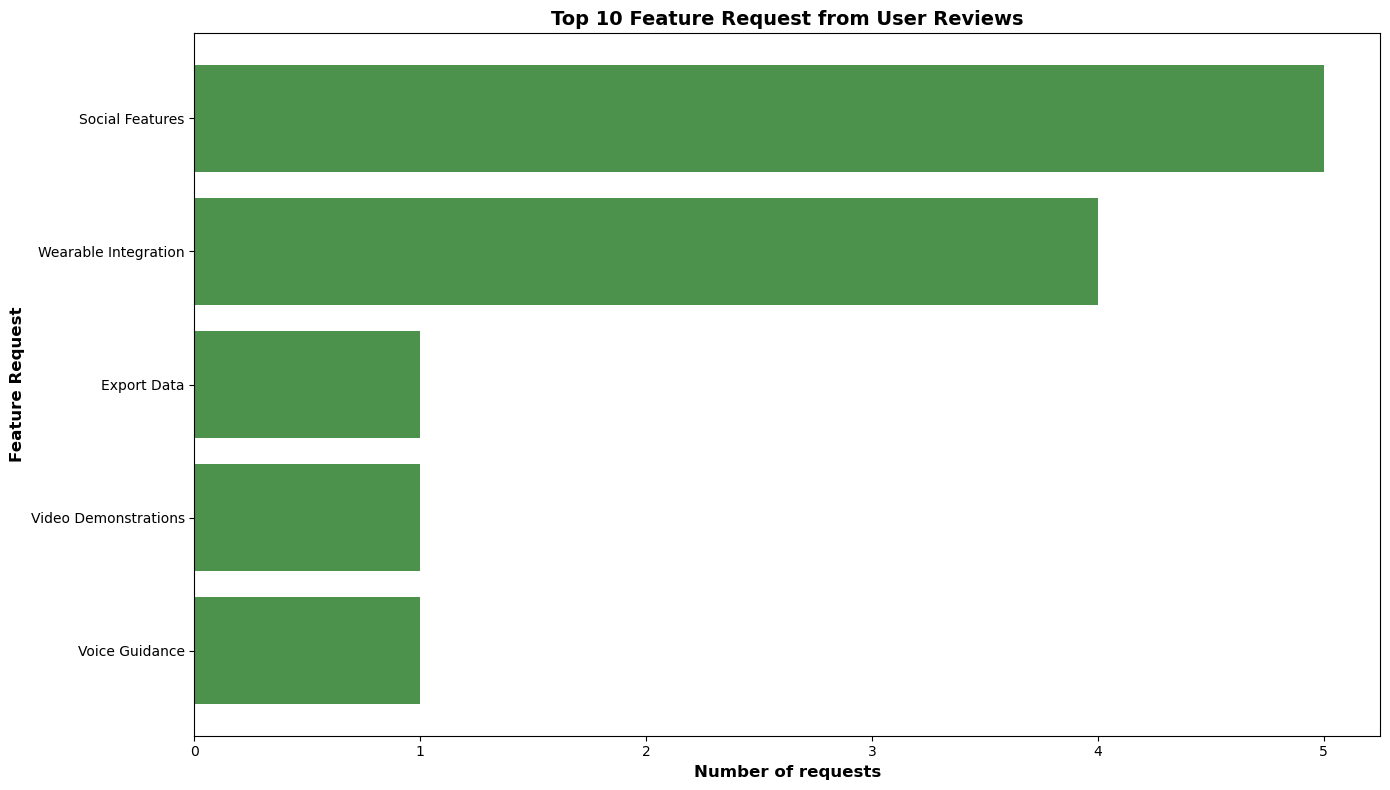


Feature requests chart saved as 'feature_requests.png'

Feature requests saved to 'feature_request.csv'


In [6]:
print("="*60)
print("Step 5: FEATURE REQUEST EXTRACTION")
print("="*60)

#Defining request patterns
request_patterns = [
    r'\bneed[s]?\b',
    r'\bshould have\b',
    r'\bwould like\b',
    r'\bwant[s]?\b',
    r'\bwish\b',
    r'\bmissing\b',
    r'\black[s]? of\b',
    r'\bdoesn\'t have\b',
    r'\bdon\'t have\b',
    r'\badd\b',
    r'\bplease add\b',
    r'\binclude\b',
    r'\brequire[s]?\b'
]

#Function to check if review contains request pattern
def contains_request(text):
    text_lower = text.lower()
    for pattern in request_patterns:
        if re.search(pattern, text_lower):
            return True 
    return False

#Filtering reviews with feature request 
request_reviews = clean_reviews_df[clean_reviews_df['Translated_Review'].apply(contains_request)]

print(f"Found {len(request_reviews)} reviews containing feature requests ({(len(request_reviews)/len(clean_reviews_df)*100):.1f} % of total)")

#Define specific feature requests to search for
specific_requests = {
    'Offline Mode': ['offline', 'without internet', 'no connection', 'offline access'],
    'Wearable Integration': ['apple watch', 'smartwatch', 'fitbit', 'garmin', 'watch integration', 'wearable'],
    'Rest Timer': ['rest timer', 'timer between sets', 'countdown', 'rest period'],
    'Dark Mode': ['dark mode', 'dark theme', 'night mode', 'black theme'],
    'Custom Workout Builder': ['custom workout', 'create workout', 'build workout', 'own workout'],
    'Social Features': ['social', 'friend', 'community', 'challenge', 'compete', 'share'],
    'Progress Photos': ['progress photo', 'picture', 'before after', 'photo tracking'],
    'Meal Planning': ['meal plan', 'diet plan', 'food plan', 'nutrition plan'],
    'Water Tracking': ['water intake', 'water tracker', 'hydration', 'drink water'],
    'Export Data': ['export', 'download data', 'backup', 'save data', 'export workout'],
    'Video Demonstrations': ['video', 'demonstration', 'exercise video', 'tutorial'],
    'Voice Guidance': ['voice', 'audio', 'speak', 'voice guide', 'audio coach']
}

#count specific feature requests
feature_request_data = []
for request_name, keywords in specific_requests.items():
    #counting mentions
    count = 0
    sentiments = []

    for idx, row in request_reviews.iterrows():
        text_lower = row['Translated_Review'].lower()
        if any(keyword in text_lower for keyword in keywords):
            count += 1
            sentiments.append(row['VaderCompound'])

    if count > 0:
        avg_sentiment = np.mean(sentiments)
        percentage = (count / len(clean_reviews_df)) * 100 

        feature_request_data.append({
            'Feature Request': request_name,
            'Request Count': count,
            'Pecentage': round(percentage, 2),
            'Avg Sentiment': round(avg_sentiment, 3)
        })

#creating feature request dataframe 
feature_request_df = pd.DataFrame(feature_request_data).sort_values('Request Count', ascending=False)
print("\nTop Feature Request:")
print("=" * 60)
print(feature_request_df.to_string(index=False))

#Visualization: Top 10 Feature Requests
plt.figure(figsize=(14,8))
top_10_requests= feature_request_df.head(10)

#Creating color map based on sentiment 
colors = ['darkgreen' if x >= 0.1 else 'orange' if x>=-0.1 else 'darkred' for x in top_10_requests['Avg Sentiment']]
plt.barh(range(len(top_10_requests)), top_10_requests['Request Count'], color= colors, alpha=0.7)
plt.yticks(range(len(top_10_requests)), top_10_requests['Feature Request'])
plt.xlabel('Number of requests', fontsize=12, fontweight='bold')
plt.ylabel('Feature Request', fontsize=12, fontweight='bold')
plt.title('Top 10 Feature Request from User Reviews', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_requests.png', dpi=300, bbox_inches='tight')
plt.show()
print("\nFeature requests chart saved as 'feature_requests.png'")

#saving feature request data 
feature_request_df.to_csv('feature_request.csv', index=False)
print("\nFeature requests saved to 'feature_request.csv'")

Step 6: EMOTION ANALYSIS USING NRX LEXICON
Analyzing emotions in reviews...

Emotion Analysis Results:
     Emotion  Word Count  Reviews with Emotion  Percentage of Reviews
         joy         134                    95                   56.5
       anger           7                     3                    1.8
     sadness           6                     4                    2.4
anticipation           4                     2                    1.2
       trust           3                     7                    4.2
     disgust           3                     2                    1.2
    surprise           2                     6                    3.6
        fear           2                     3                    1.8
EMOTION INSIGHTS:

Positive Emotion Words: 143

Negative Emotion Words: 18

Positive/Negative Ratio: 7.94


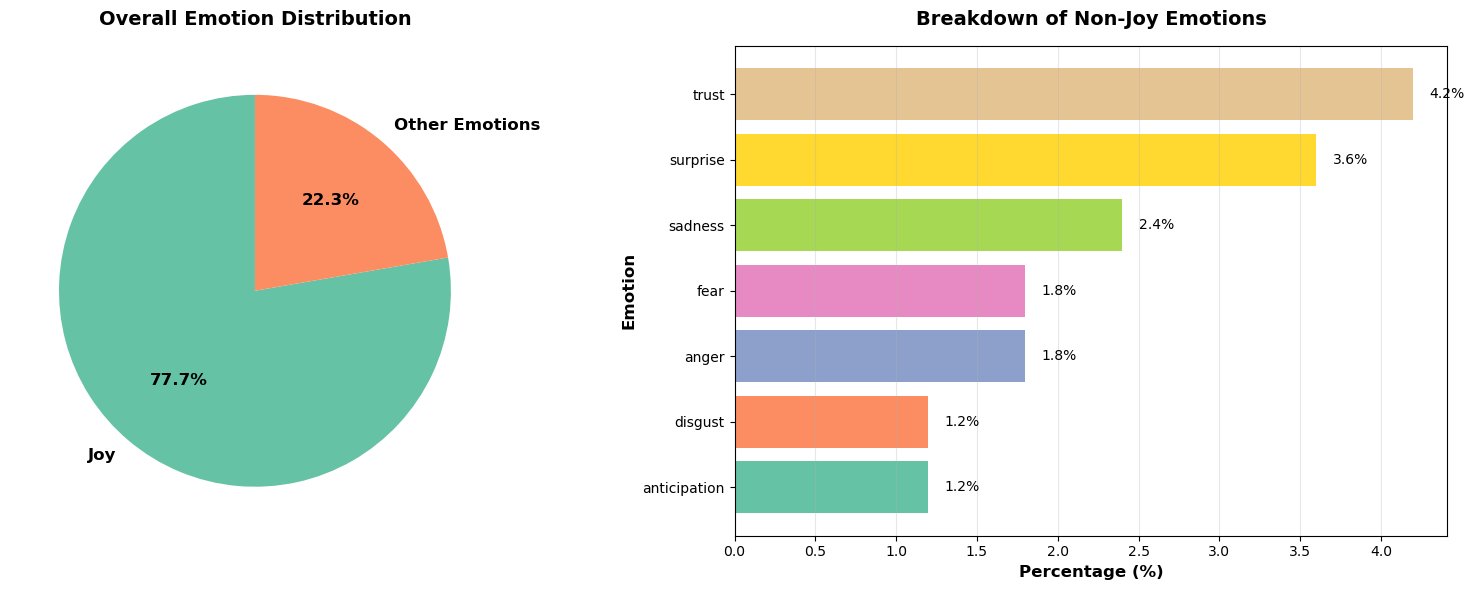


 Combined emotion chart saved as 'emotion_chart.png'


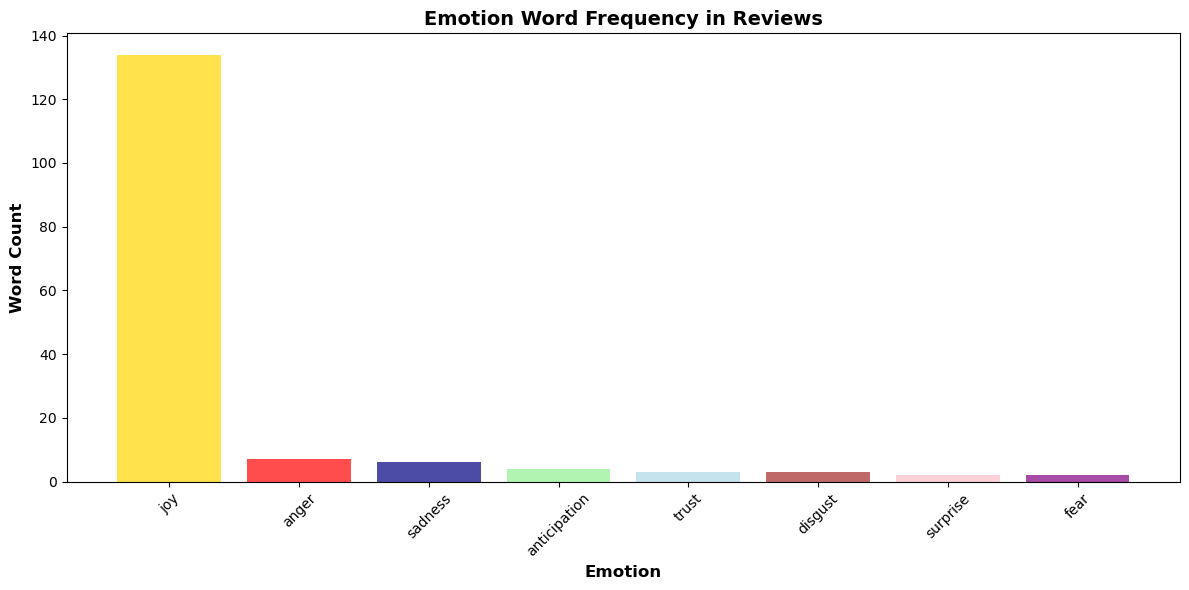

Emotion bar chart saved as 'emotion_bar_chart.png'
Emotion analysis saved to 'emotion_analysis.csv'


In [7]:
print("="*60)
print("Step 6: EMOTION ANALYSIS USING NRX LEXICON")
print("="*60)

#NRC Emotion Lexicon 
nrc_emotions = {
    'joy': ['happy', 'great', 'love', 'excellent', 'amazing', 'fantastic', 'wonderful', 
            'good', 'best', 'enjoy', 'loved', 'awesome', 'perfect', 'nice'],
    'trust': ['reliable', 'trust', 'secure', 'safe', 'confidence', 'depend', 'consistent',
              'stable', 'honest', 'credible'],
    'anticipation': ['hope', 'expect', 'excited', 'anticipate', 'looking forward', 'eager',
                     'ready', 'prepared', 'upcoming', 'future'],
    'surprise': ['wow', 'amazing', 'surprised', 'unexpected', 'incredible', 'astonishing',
                 'remarkable', 'shocking'],
    'anger': ['angry', 'frustrate', 'annoying', 'irritating', 'mad', 'furious', 'hate',
              'terrible', 'awful', 'worst', 'disappointed', 'frustration'],
    'fear': ['afraid', 'scared', 'worry', 'concerned', 'anxious', 'nervous', 'fear',
             'worried', 'concern'],
    'sadness': ['sad', 'unhappy', 'depressed', 'disappointed', 'unfortunate', 'regret',
                'miss', 'lose', 'loss', 'poor'],
    'disgust': ['disgusted', 'gross', 'horrible', 'nasty', 'awful', 'terrible', 'bad',
                'poor', 'sucks', 'trash']
}

#function to count emotion words in text 
def count_emotions(text):
    text_lower = text.lower()
    tokens = word_tokenize(text_lower)

    emotion_counts= {emotion: 0 for emotion in nrc_emotions.keys()}

    for token in tokens:
        for emotion, words in nrc_emotions.items():
            if token in words:
                emotion_counts[emotion] += 1

    return emotion_counts

#apply emotion analysis to all reviews
print("Analyzing emotions in reviews...\n")

emotion_results = clean_reviews_df['Translated_Review'].apply(count_emotions)

#converting to dataframe
emotion_df = pd.DataFrame(emotion_results.tolist())

#add emotion columns to main dataframe
for emotion in nrc_emotions.keys():
    clean_reviews_df[f'emotion_{emotion}'] = emotion_df[emotion]

#calculating overall emotion distribution 
emotion_summary = emotion_df.sum().sort_values(ascending=False)

#calculating percentage of reviews containing each emotion 
emotion_presence = (emotion_df>0).sum()
emotion_presence_pct = (emotion_presence / len(clean_reviews_df)) * 100 

emotion_analysis_df = pd.DataFrame ({
    'Emotion': emotion_summary.index,
    'Word Count': emotion_summary.values,
    'Reviews with Emotion': emotion_presence.values,
    'Percentage of Reviews': emotion_presence_pct.values.round(1)
})

print("Emotion Analysis Results:")
print("=" * 60)
print(emotion_analysis_df.to_string(index=False))

#Insights
print("=" * 60)
print("EMOTION INSIGHTS:")
print("=" * 60)

positive_emotions = ['joy', 'trust', 'anticipation', 'surprise']
negative_emotions = ['anger', 'fear', 'sadness', 'disgust']

positive_count = emotion_df[positive_emotions].sum().sum()
negative_count = emotion_df[negative_emotions].sum().sum()

print(f"\nPositive Emotion Words: {positive_count}")
print(f"\nNegative Emotion Words: {negative_count}")
print(f"\nPositive/Negative Ratio: {(positive_count/negative_count):.2f}")

# Visualization 1: Combined View - Pie for Joy, Bar for Others
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Left: Simple Pie Chart showing Joy vs Others
joy_vs_others = pd.DataFrame({
    'Category': ['Joy', 'Other Emotions'],
    'Percentage of Reviews': [
        emotion_analysis_df[emotion_analysis_df['Emotion'] == 'joy']['Percentage of Reviews'].values[0],
        emotion_analysis_df[emotion_analysis_df['Emotion'] != 'joy']['Percentage of Reviews'].sum()
    ]
})

colors_simple = ['#66c2a5', '#fc8d62']
ax1.pie(joy_vs_others['Percentage of Reviews'], 
        labels=joy_vs_others['Category'],
        autopct='%1.1f%%',
        startangle=90,
        colors=colors_simple,
        textprops={'fontsize': 12, 'weight': 'bold'})
ax1.set_title('Overall Emotion Distribution', fontsize=14, fontweight='bold', pad=15)

# Right: Bar Chart for detailed breakdown of non-joy emotions
other_emotions = emotion_analysis_df[emotion_analysis_df['Emotion'] != 'joy'].sort_values('Percentage of Reviews', ascending=True)

bars = ax2.barh(other_emotions['Emotion'], other_emotions['Percentage of Reviews'], 
                color=sns.color_palette('Set2', len(other_emotions)))
ax2.set_xlabel('Percentage (%)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Emotion', fontsize=12, fontweight='bold')
ax2.set_title('Breakdown of Non-Joy Emotions', fontsize=14, fontweight='bold', pad=15)
ax2.grid(axis='x', alpha=0.3)

# Adding percentage labels on bars
for i, (bar, pct) in enumerate(zip(bars, other_emotions['Percentage of Reviews'])):
    ax2.text(pct + 0.1, i, f'{pct:.1f}%', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('emotion_chart.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n Combined emotion chart saved as 'emotion_chart.png'")


#Visualization 2: Emotion Word Counts (bar chart) 
plt.figure(figsize=(12,6))
colors_map = {  'joy': 'gold', 'trust': 'lightblue', 'anticipation': 'lightgreen', 'surprise': 'pink',
    'anger': 'red', 'fear': 'purple', 'sadness': 'navy', 'disgust': 'brown'
}
colors_list = [colors_map[emotion] for emotion in emotion_analysis_df['Emotion']]

plt.bar(emotion_analysis_df['Emotion'], emotion_analysis_df['Word Count'], color=colors_list, alpha=0.7)
plt.xlabel('Emotion', fontsize=12, fontweight='bold')
plt.ylabel('Word Count', fontsize= 12, fontweight='bold')
plt.title('Emotion Word Frequency in Reviews', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('emotion_bar_chart.png', dpi=300, bbox_inches='tight')
plt.show()

print("Emotion bar chart saved as 'emotion_bar_chart.png'")

#saving emotion analysis data
emotion_analysis_df.to_csv('emotion_analysis.csv', index=False)
print("Emotion analysis saved to 'emotion_analysis.csv'")

In [8]:
print("="*60)
print("Step 7: COMPETITIVE ANALYSIS")
print("="*60)

#Getting unique apps in dataset 
unique_apps = clean_reviews_df['App'].unique()
print(f"Number of unique apps in dataset:{len(unique_apps)}")

if len(unique_apps)> 1:
    #Performace competitive analysis
    competitive_data = []

    for app in unique_apps: 
        app_reviews = clean_reviews_df[clean_reviews_df['App'] == app]

        if len(app_reviews) >= 5: #only including apps with at least 5 reviews
            avg_rating = app_reviews['Rating'].mean()
            avg_sentiment = app_reviews['VaderCompound'].mean()
            review_count = len(app_reviews)

            #finding most negatice feature
            feature_sentiments = {}
            for category in feature_categories.keys():
                feature_reviews = app_reviews[app_reviews[f'mentions_{category}'] == True]
                if len(feature_reviews) > 0:
                    feature_sentiments[category] = feature_reviews['VaderCompound'].mean()


            top_complaint = min(feature_sentiments, key=feature_sentiments.get) if feature_sentiments else 'N/A'

            top_praise = max(feature_sentiments, key=feature_sentiments.get) if feature_sentiments else 'N/A'

            competitive_data.append({
                'App Name': app,
                'Review Count': review_count,
                'Avg Rating': round(avg_rating, 2),
                'Avg Sentiment': round(avg_sentiment, 3),
                'Top Complaint': top_complaint,
                'Top Praise': top_praise
            })

    competitive_df = pd.DataFrame(competitive_data).sort_values('Avg Rating', ascending=False)

    print("\nCompetitive Analysis:")
    print("=" * 60)
    print(competitive_df.to_string(index=False))

print("\n" + "="*60)
print("GAP ANALYSIS")
print("="*60)


# Calculating market averages
avg_rating_market = competitive_df['Avg Rating'].mean()
avg_sentiment_market = competitive_df['Avg Sentiment'].mean()
    
# Identifying market leader and laggard
market_leader = competitive_df.iloc[0]  # Highest avg rating (already sorted)
market_laggard = competitive_df.iloc[-1]  # Lowest avg rating
    
print(f"\nMARKET BENCHMARKS:")
print(f"Average Rating: {avg_rating_market:.2f}")
print(f"Average Sentiment: {avg_sentiment_market:.3f}")
    
print(f"\nMARKET LEADER: {market_leader['App Name']}")
print(f"Rating: {market_leader['Avg Rating']}")
print(f"Sentiment: {market_leader['Avg Sentiment']}")
print(f"Strongest Feature: {market_leader['Top Praise']}")
print(f"Weakest Feature: {market_leader['Top Complaint']}")
    
print(f"\nMARKET LAGGARD: {market_laggard['App Name']}")
print(f"Rating: {market_laggard['Avg Rating']}")
print(f"Sentiment: {market_laggard['Avg Sentiment']}")
print(f"Strongest Feature: {market_laggard['Top Praise']}")
print(f"Weakest Feature: {market_laggard['Top Complaint']}")
    
# Performance gaps for each app
print("\n" + "="*60)
print("PERFORMANCE GAPS (vs Market Average)")
print("="*60)
    
gap_data = []
    
for _, row in competitive_df.iterrows():
    rating_gap = row['Avg Rating'] - avg_rating_market
    sentiment_gap = row['Avg Sentiment'] - avg_sentiment_market
        
    rating_status = "Above" if rating_gap > 0 else "Below"
    sentiment_status = "Above" if sentiment_gap > 0 else "Below"
        
    print(f"\n{row['App Name']}:")
    print(f"  Rating Gap: {rating_gap:+.2f} ({rating_status} average)")
    print(f"  Sentiment Gap: {sentiment_gap:+.3f} ({sentiment_status} average)")
        
    gap_data.append({
        'App Name': row['App Name'],
        'Rating Gap': round(rating_gap, 2),
        'Sentiment Gap': round(sentiment_gap, 3),
        'Rating Status': 'Above Average' if rating_gap > 0 else 'Below Average',
        'Sentiment Status': 'Above Average' if sentiment_gap > 0 else 'Below Average'
        })
    
gap_df = pd.DataFrame(gap_data)

# Key Insights
print("\n" + "="*60)
print("KEY INSIGHTS")
print("="*60)

above_avg = gap_df[gap_df['Rating Gap'] > 0]
below_avg = gap_df[gap_df['Rating Gap'] < 0]

print(f"\nApps Above Market Average ({len(above_avg)}):")
for _, row in above_avg.iterrows():
    print(f"{row['App Name']}: +{row['Rating Gap']:.2f} rating gap")

print(f"\nApps Below Market Average ({len(below_avg)}):")
for _, row in below_avg.iterrows():
    print(f"{row['App Name']}: {row['Rating Gap']:.2f} rating gap")

# Save data
competitive_df.to_csv('competitive_analysis.csv', index=False)
gap_df.to_csv('gap_analysis.csv', index=False)

print("\n" + "="*60)
print("Analysis complete! Files saved:")
print("competitive_analysis.csv")
print("gap_analysis.csv")
print("="*60)

Step 7: COMPETITIVE ANALYSIS
Number of unique apps in dataset:5

Competitive Analysis:
                                  App Name  Review Count  Avg Rating  Avg Sentiment    Top Complaint     Top Praise
30 Day Fitness Challenge - Workout at Home            30         4.8          0.573 Customer Support  Premium/Price
               Home Workout - No Equipment            26         4.8          0.725 Sync/Integration Bugs/Technical
            Calorie Counter - MyFitnessPal            95         4.6          0.398   Bugs/Technical     Motivation
                          7 Minute Workout            11         4.5          0.668 Workout Tracking     Motivation
                                    Fitbit             6         3.9          0.073 Customer Support User Interface

GAP ANALYSIS

MARKET BENCHMARKS:
Average Rating: 4.52
Average Sentiment: 0.487

MARKET LEADER: 30 Day Fitness Challenge - Workout at Home
Rating: 4.8
Sentiment: 0.573
Strongest Feature: Premium/Price
Weakest Feature:

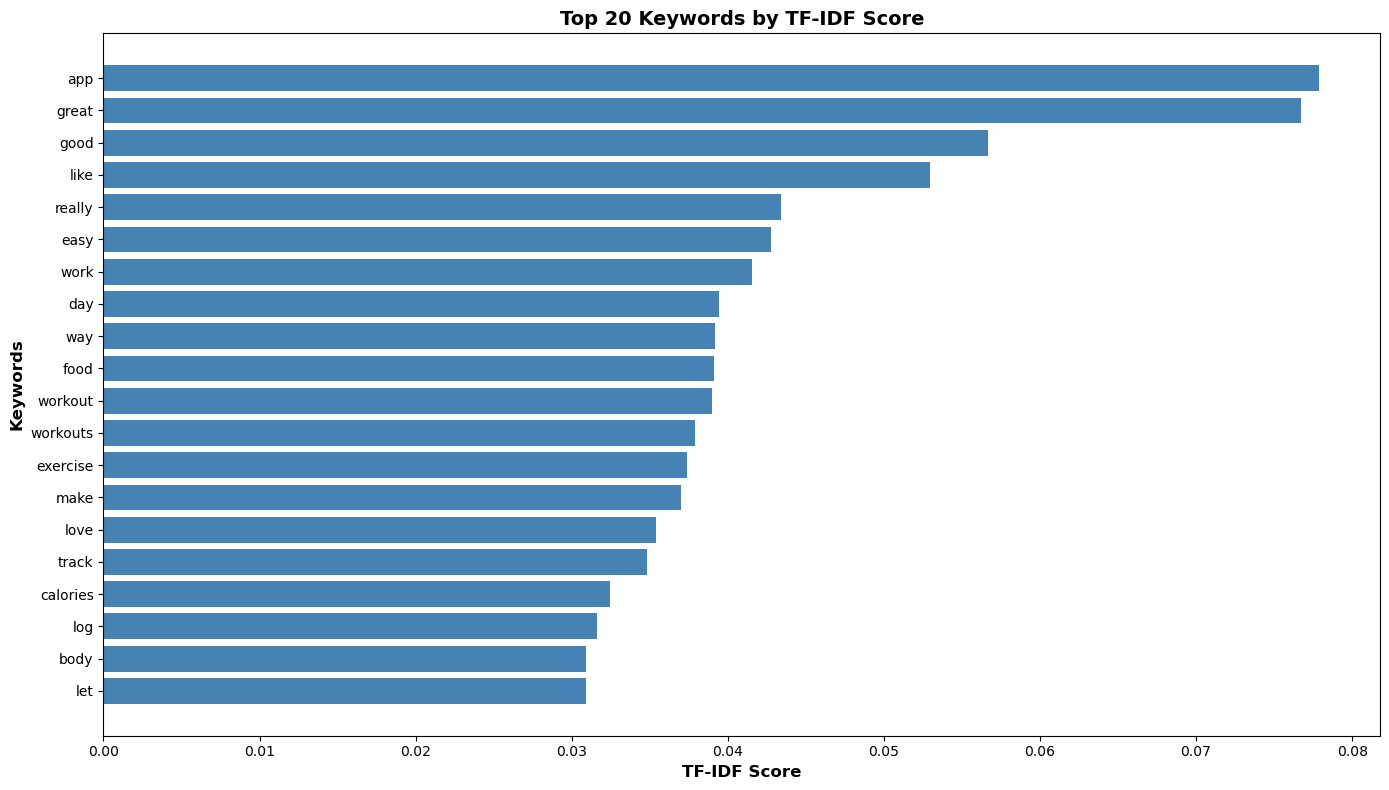


Chart saved as 'top_keywords_tfidf.png'


In [9]:
#Additional visualization
#Top 20 keywords 

plt.figure(figsize=(14,8))
top_20 = keyword_df.head(20)
plt.barh(range(len(top_20)), top_20['tfidf_score'], color='steelblue')
plt.yticks(range(len(top_20)), top_20['keyword'])
plt.xlabel('TF-IDF Score', fontsize=12, fontweight='bold')
plt.ylabel('Keywords', fontsize=12, fontweight='bold')
plt.title('Top 20 Keywords by TF-IDF Score', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('top_keywords_tfidf.png', dpi=300, bbox_inches='tight')
plt.show()
print("\nChart saved as 'top_keywords_tfidf.png'")